# Importing all neccessary libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading csv file

In [4]:
csv_path = 'data/scraped_data_team_31.csv'
df = pd.read_csv(csv_path)


# Analysis

In [5]:
df.head()


,University Name,Location,Founded Year,University ID,Online Status,Admission Status,Course Name,Language,Mode,Fee Domestic,Fee International
0,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Accounting,English,Full-time,"AZN 2,500","AZN 4,590"
1,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Administration,English,Full-time,"AZN 2,100","AZN 4,590"
2,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Biology,English,Full-time,"AZN 2,700","AZN 4,590"
3,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Business,English,Full-time,"AZN 2,101","AZN 4,590"
4,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Design,English,Full-time,"AZN 2,101","AZN 4,590"


In [6]:
df.isnull().sum()

University Name       0
Location              0
Founded Year          0
University ID         0
Online Status        33
Admission Status      0
Course Name           0
Language              0
Mode                  0
Fee Domestic          0
Fee International     0
dtype: int64

In [7]:
df.info()   # Summary of dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   University Name    367 non-null    object
 1   Location           367 non-null    object
 2   Founded Year       367 non-null    int64 
 3   University ID      367 non-null    int64 
 4   Online Status      334 non-null    object
 5   Admission Status   367 non-null    object
 6   Course Name        367 non-null    object
 7   Language           367 non-null    object
 8   Mode               367 non-null    object
 9   Fee Domestic       367 non-null    object
 10  Fee International  367 non-null    object
dtypes: int64(2), object(9)
memory usage: 31.7+ KB


In [8]:
df.describe() # Statistics for numeric columns

,Founded Year,University ID
count,367.000000,3.670000e+02
mean,1967.046322,1.003100e+09
std,30.128151,7.472062e+00
min,1919.000000,1.003100e+09
25%,1930.000000,1.003100e+09
50%,1975.000000,1.003100e+09
75%,1992.000000,1.003100e+09
max,2006.000000,1.003100e+09


In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
362     True
363     True
364     True
365     True
366    False
Length: 367, dtype: bool

In [10]:
df.duplicated().sum()

142

In [11]:
df.nunique()

University Name      14
Location              1
Founded Year         11
University ID        14
Online Status         2
Admission Status      1
Course Name          47
Language              4
Mode                  2
Fee Domestic         29
Fee International    17
dtype: int64

In [12]:
df.head() 

,University Name,Location,Founded Year,University ID,Online Status,Admission Status,Course Name,Language,Mode,Fee Domestic,Fee International
0,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Accounting,English,Full-time,"AZN 2,500","AZN 4,590"
1,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Administration,English,Full-time,"AZN 2,100","AZN 4,590"
2,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Biology,English,Full-time,"AZN 2,700","AZN 4,590"
3,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Business,English,Full-time,"AZN 2,101","AZN 4,590"
4,Western Caspian University,Azerbaijan,1991,1003100014,Online 4 weeks ago,Admissions open,Design,English,Full-time,"AZN 2,101","AZN 4,590"


# Cleaning

In [13]:
df.drop_duplicates(inplace=True) # dropping duplicates
df.duplicated().sum() # checking

0

In [14]:
#  Handling 'Fee Domestic' and 'Fee International' are numerical columns
df['Fee Domestic'] = df['Fee Domestic'].replace({'AZN': '', ',': ''}, regex=True).astype(float)
df['Fee International'] = df['Fee International'].replace({'AZN': '', ',': ''}, regex=True).astype(float)

# Checking
df.info()
df.describe() # Statistics for numeric columns

<class 'pandas.core.frame.DataFrame'>
Index: 225 entries, 0 to 366
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   University Name    225 non-null    object 
 1   Location           225 non-null    object 
 2   Founded Year       225 non-null    int64  
 3   University ID      225 non-null    int64  
 4   Online Status      199 non-null    object 
 5   Admission Status   225 non-null    object 
 6   Course Name        225 non-null    object 
 7   Language           225 non-null    object 
 8   Mode               225 non-null    object 
 9   Fee Domestic       225 non-null    float64
 10  Fee International  225 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 21.1+ KB


,Founded Year,University ID,Fee Domestic,Fee International
count,225.000000,2.250000e+02,225.000000,225.000000
mean,1969.924444,1.003100e+09,2182.391111,3077.151111
std,29.440900,7.431011e+00,1273.813214,3507.285435
min,1919.000000,1.003100e+09,0.000000,794.000000
25%,1950.000000,1.003100e+09,1000.000000,1700.000000
50%,1991.000000,1.003100e+09,2101.000000,3060.000000
75%,1992.000000,1.003100e+09,3100.000000,4250.000000
max,2006.000000,1.003100e+09,5423.000000,51000.000000


In [15]:
df = df.drop(["Location", "Online Status", "Admission Status", "University ID"], axis=1)
df.head()

,University Name,Founded Year,Course Name,Language,Mode,Fee Domestic,Fee International
0,Western Caspian University,1991,Accounting,English,Full-time,2500.0,4590.0
1,Western Caspian University,1991,Administration,English,Full-time,2100.0,4590.0
2,Western Caspian University,1991,Biology,English,Full-time,2700.0,4590.0
3,Western Caspian University,1991,Business,English,Full-time,2101.0,4590.0
4,Western Caspian University,1991,Design,English,Full-time,2101.0,4590.0


# Outlier Detection

In [16]:
import pandas as pd
import numpy as np

# Function for checking whether dataset has outliers or not by considering IQR
def check_outliers(dataframe):
    outliers = {}
    for column in dataframe.select_dtypes(include=[np.number]).columns:
        Q1 = dataframe[column].quantile(0.25)  
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1 
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identifying outliers
        outliers[column] = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    
    return outliers

# Checking outliers
outliers = check_outliers(df)

# Displaying outliers for every column
for column, rows in outliers.items():
    print(f"Outliers in column '{column}':")
    if not rows.empty:
        print(rows)
    else:
        print("No outliers found.")


Outliers in column 'Founded Year':
No outliers found.
Outliers in column 'Fee Domestic':
No outliers found.
Outliers in column 'Fee International':
               University Name  Founded Year Course Name Language       Mode  \
34  Western Caspian University          1991  Management  English  Full-time   

    Fee Domestic  Fee International  
34        3162.0            51000.0  


In [17]:
df = df.drop(index=34) # Applied removing method for handling outliers because it's just one outlier.

In [18]:
# Again Checking if outliers remains or not
outliers = check_outliers(df)

# Display outliers for each column
for column, rows in outliers.items():
    print(f"Outliers in column of '{column}':")
    if not rows.empty:
        print(rows)
    else:
        print("No outliers found.")


Outliers in column of 'Founded Year':
No outliers found.
Outliers in column of 'Fee Domestic':
No outliers found.
Outliers in column of 'Fee International':
No outliers found.


In [19]:
df.columns

Index(['University Name', 'Founded Year', 'Course Name', 'Language', 'Mode',
       'Fee Domestic', 'Fee International'],
      dtype='object')

In [20]:
# A Dictionary for renaming all column names
columns_mapping = {
    'University Name': 'university_name',
    'Founded Year': 'founded_year',
    'Course Name': 'course_name',
    'Language': 'language',
    'Mode': 'mode',
    'Fee Domestic': 'fee_domestic',
    'Fee International': 'fee_international'
}

# Renaming columns using map method of pandas
df.columns = df.columns.map(columns_mapping)

# Display the renamed columns
df.columns


Index(['university_name', 'founded_year', 'course_name', 'language', 'mode',
       'fee_domestic', 'fee_international'],
      dtype='object')

# Correlation for numerical columns

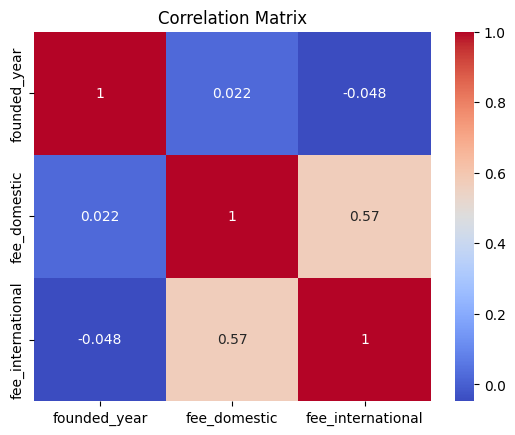

In [21]:
# Defining numerical columns out of all dataset
numeric_df = df.select_dtypes(include=['number'])

# Computing correlation matrix by corr() fuction
correlation_matrix = numeric_df.corr()

# Plotting heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


# Which universities has more courses

/var/folders/7m/k3pkxcmj2k5g8__jqnl12vcc0000gn/T/ipykernel_17283/1417291508.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='university_name', palette='viridis')


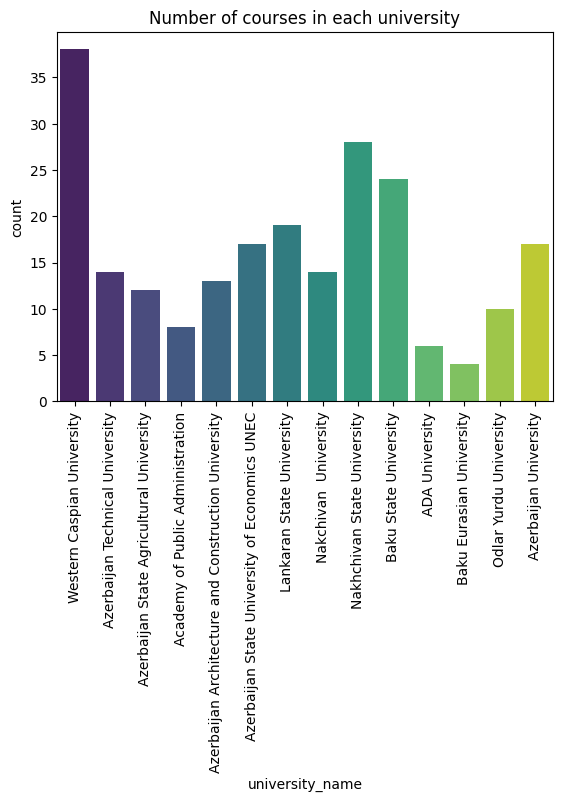

In [22]:
sns.countplot(data=df, x='university_name', palette='viridis')
plt.title('Number of courses in each university')
plt.xticks(rotation=90)
plt.show()


# A

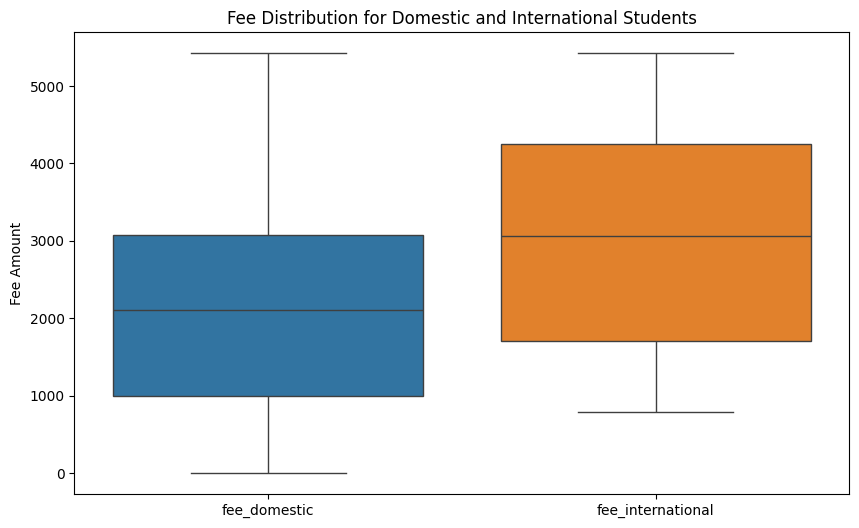

In [23]:
# Boxplot for Fee Domestic vs Fee International
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['fee_domestic', 'fee_international']])
plt.title('Fee Distribution for Domestic and International Students')
plt.ylabel('Fee Amount')
plt.show()


# Average Fees for Domestic and International Students by Course

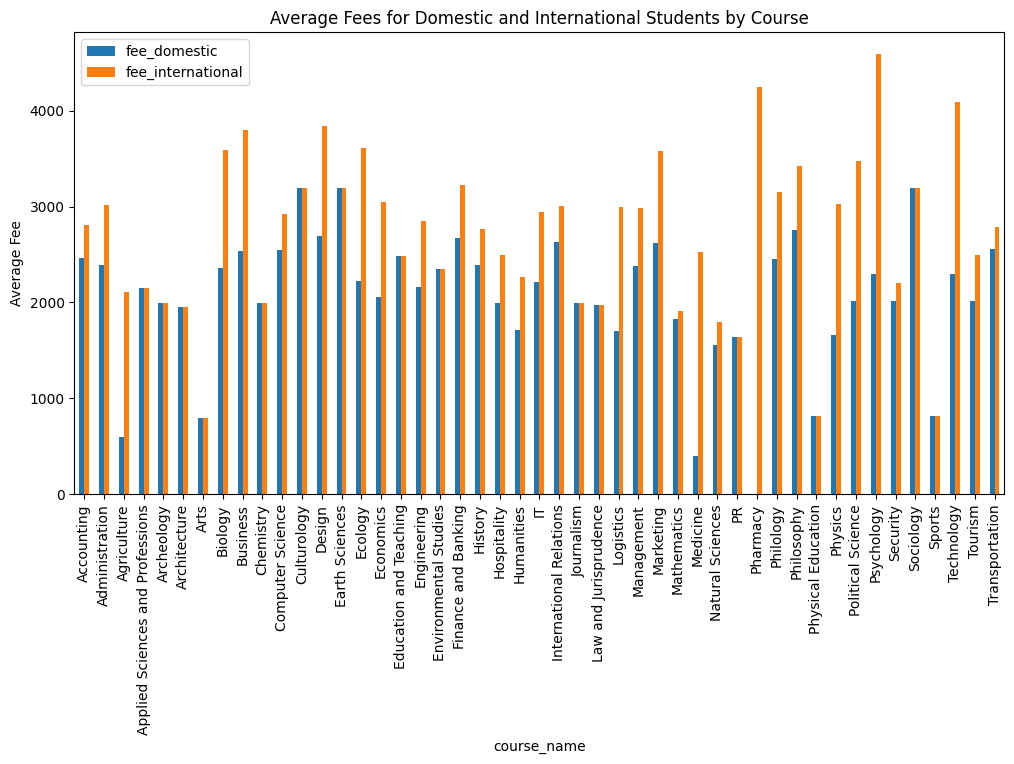

In [24]:
# Calculating mean fee for domestic and international via grouping by Course Name 
avg_fees = df.groupby('course_name')[['fee_domestic', 'fee_international']].mean().reset_index()

# Plot the bar chart
avg_fees.plot(kind='bar', x='course_name', y=['fee_domestic', 'fee_international'], figsize=(12, 6), title="Average Fees for Domestic and International Students by Course")
plt.ylabel('Average Fee')
plt.xticks(rotation=90)
plt.show()


# Fee Comparison by Mode of Study

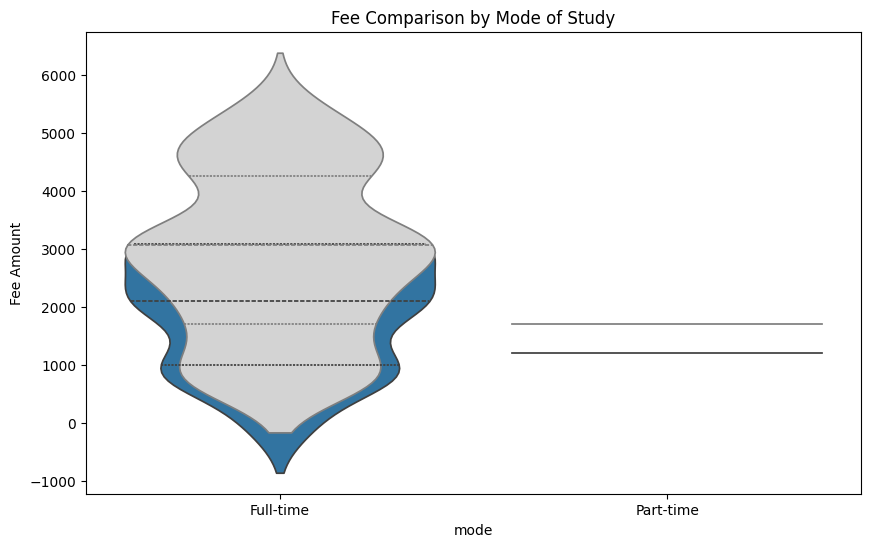

'\nFor Full-time mode, the distribution is wider with higher peaks around 2000 and 3000.\nFor Part-time mode is showing that most part-time students have fees clustered around 1000 to 2000. So, lower than Full-time.\n'

In [25]:
# Violin plot for Fee Domestic and Fee International by Mode
plt.figure(figsize=(10, 6))
sns.violinplot(x='mode', y='fee_domestic', data=df, inner="quart")
sns.violinplot(x='mode', y='fee_international', data=df, inner="quart", color='lightgray')
plt.title('Fee Comparison by Mode of Study')
plt.ylabel('Fee Amount')
plt.show()

"""
For Full-time mode, the distribution is wider with higher peaks around 2000 and 3000.
For Part-time mode is showing that most part-time students have fees clustered around 1000 to 2000. So, lower than Full-time.
"""

# Fees for Domestic and International Students for Each University


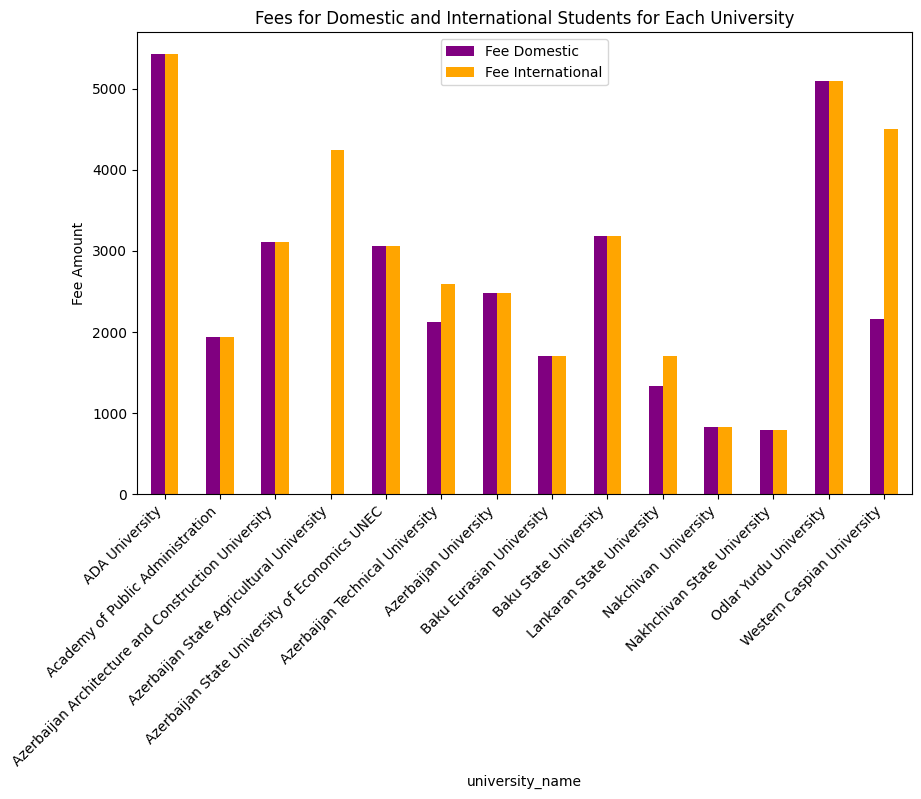

In [26]:
# Calculating mean fees by grouping by university name
fees = df.groupby('university_name')[['fee_domestic', 'fee_international']].mean()

# Plotting bar chart
fees.plot(kind='bar', figsize=(10, 6), color=['purple', 'orange'])

# Adding labels and title
plt.ylabel('Fee Amount')
plt.title('Fees for Domestic and International Students for Each University')
plt.xticks(rotation=45, ha='right')
plt.legend(['Fee Domestic', 'Fee International'])

plt.show()


# Saving processed data

In [27]:
df.to_csv('data/processed_data_team_31.csv', index=False)